# 📊 Exploratory Data Analysis (EDA) — Fantasy Premier League 2024/2025

## 1. Introdução

Este notebook apresenta uma Análise Exploratória de Dados (EDA) realizada sobre um conjunto de dados proveniente do repositório público *Fantasy Premier League (FPL)*, disponível em:
https://github.com/vaastav/Fantasy-Premier-League

O objetivo central da análise é preparar um dataset limpo, estruturado e apropriado para a aplicação de algoritmos de **mineração de regras de associação**, recorrendo à informação de desempenho dos jogadores ao longo das jornadas da época 2024/2025. Toda a investigação é conduzida com foco na identificação de padrões entre eventos de jogo, métricas de performance e resultados estatísticos dos jogadores.

### 1.1. O que é o Fantasy Premier League?

O *Fantasy Premier League* (FPL) é um jogo global onde milhões de utilizadores constroem equipas virtuais constituídas por jogadores reais da **Premier League inglesa**.  
Em cada jornada, os jogadores acumulam pontos com base no seu desempenho real: golos, assistências, clean sheets, minutos jogados, bónus, entre outros critérios.

O repositório utilizado nesta análise contém extrações completas da API do FPL, reunindo milhares de registos sobre estatísticas detalhadas de cada jogador em cada jornada, variando entre métricas tradicionais (golos, assistências) e métricas derivadas (influence, threat, creativity).


### 1.2. Seleção do dataset `merged_gw.csv`

Apesar de o repositório conter dezenas de ficheiros com diferentes tipos de dados (preços, estatísticas históricas, equipas, metadata de jogadores, etc.), apenas um ficheiro foi selecionado:

**`data/2024-25/gws/merged_gw.csv`**

Este dataset agrega, numa única estrutura, **todos os eventos registados em cada jornada**, para cada jogador, incluindo:

- pontos,
- minutos jogados,
- ações ofensivas e defensivas,
- contribuições esperadas (xG, xA),
- métricas avançadas,
- preço e variações,
- dados de posse e seleção,
- ações relevantes para a performance individual.

Este conjunto de dados é ideal para regras de associação, uma vez que cada linha representa uma "transação" de performance do jogador numa jornada, permitindo identificar padrões entre diferentes características.


### 1.3. Objetivo do notebook

O objetivo deste notebook consiste em:

1. Descrever e compreender o dataset selecionado.  
2. Realizar uma EDA aprofundada, abrangendo:
   - estrutura dos dados,  
   - análise estatística,  
   - identificação de problemas,  
   - tratamento e limpeza,  
   - estudo de distribuições e correlações.
3. Transformar variáveis contínuas em atributos binários adequados ao algoritmo Apriori.
4. Construir um dataset final preparado para extração de regras de associação.

Ao final da EDA, o dataset estará limpo, consistente e devidamente transformado, constituindo a base para a fase de mineração de padrões.

---

## 2. Carregamento do Dataset

Para iniciar a EDA, procede-se ao carregamento das principais bibliotecas necessárias para manipulação e visualização dos dados, seguido da leitura do ficheiro `merged_gw.csv`, localizado na estrutura de pastas do repositório.

Este ficheiro localmente encontra-se na pasta `data\merger_gw.csv`

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# use a more tolerant CSV parser to skip malformed lines that cause the ParserError
df = pd.read_csv("data/merged_gw.csv", engine='python', sep=',', on_bad_lines='skip')

df.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,modified,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,0.01,0.01,0.0,1.02,6,1,0,3.6,22.8,2024-08-17T14:00:00Z,62,False,16,0,0,0,0,1,0,4339,1,1,1,0.0,2,0,0,0,50,False,0,1
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,0.00,0.00,0.0,0.00,6,0,0,0.0,0.0,2024-08-17T14:00:00Z,0,False,3,0,0,0,0,1,0,33324,0,1,1,0.0,0,0,0,0,45,True,0,1
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,0.00,0.00,0.0,0.00,2,0,0,0.0,0.0,2024-08-17T14:00:00Z,0,False,20,0,0,0,0,1,0,8462,0,0,2,0.0,0,0,0,0,50,True,0,1
3,Malcolm Ebiowei,MID,Crystal Palace,0.0,0,0,0,0,0.0,197,0.00,0.00,0.0,0.00,8,0,0,0.0,0.0,2024-08-18T13:00:00Z,0,False,4,0,0,0,0,1,0,716,0,1,2,0.0,0,0,0,0,45,False,0,1
4,Ben Brereton Díaz,MID,Southampton,1.0,0,0,-2,0,14.0,584,0.02,0.32,0.3,0.25,5,1,0,3.3,2.6,2024-08-17T14:00:00Z,70,False,15,0,0,0,0,1,0,66244,1,0,1,16.0,1,0,0,0,55,False,1,1


---

## 3. Estrutura do Dataset

Neste ponto, analisa-se a estrutura geral do dataset, incluindo:

- número de observações,
- número de atributos,
- tipos de dados,
- primeiras entradas,
- resumo estatístico.

Este entendimento inicial permite identificar possíveis inconsistências, escolhas de tipagem incorreta e o nível geral de granularidade da informação disponível.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14178 entries, 0 to 14177
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        14178 non-null  object 
 1   position                    14178 non-null  object 
 2   team                        14178 non-null  object 
 3   xP                          14178 non-null  float64
 4   assists                     14178 non-null  int64  
 5   bonus                       14178 non-null  int64  
 6   bps                         14178 non-null  int64  
 7   clean_sheets                14178 non-null  int64  
 8   creativity                  14178 non-null  float64
 9   element                     14178 non-null  int64  
 10  expected_assists            14178 non-null  float64
 11  expected_goal_involvements  14178 non-null  float64
 12  expected_goals              14178 non-null  float64
 13  expected_goals_conceded     141

In [14]:
df.describe(include='all')

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,modified,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
count,14178,14178,14178,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.00000,14178.000000,14178.000000,14178.000000,14178.000000,14178,14178.000000,14178,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,1.417800e+04,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,1.417800e+04,1.417800e+04,1.417800e+04,14178.000000,14178,14178.000000,14178.000000
unique,724,4,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,Raúl Jiménez,MID,Brighton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-21T14:00:00Z,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
freq,21,6436,947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,398,NaN,14178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7110,NaN,NaN
mean,NaN,NaN,NaN,1.174129,0.038369,0.093031,5.023769,0.076456,4.679539,340.039780,0.028891,0.073158,0.044272,0.481510,107.65115,0.483354,0.042742,1.566695,6.752560,NaN,29.035478,NaN,10.495204,0.001199,0.000564,0.000564,0.001975,11.215475,0.094442,2.330977e+05,0.324305,1.480251,1.521865,4.249189,1.203061,4.119439e+01,1.829234e+04,1.825072e+04,49.558400,NaN,0.065454,11.215475
std,NaN,NaN,NaN,1.794372,0.208977,0.456648,9.576491,0.265736,10.607323,196.844226,0.087781,0.193644,0.151994,0.783524,60.55080,0.934950,0.223804,2.828839,12.586388,NaN,38.554664,NaN,5.768158,0.036589,0.023748,0.023748,0.044397,6.046624,0.642730,6.312137e+05,0.468131,1.266242,1.186369,10.993013,2.361287,8.109667e+04,6.851884e+04,6.286187e+04,10.509246,NaN,0.247333,6.046624
min,NaN,NaN,NaN,-2.200000,0.000000,0.000000,-25.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-5.000000,-2.741008e+06,0.000000e+00,0.000000e+00,39.000000,NaN,0.000000,1.000000
25%,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,169.000000,0.000000,0.000000,0.000000,0.000000,55.00000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,5.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,5.575250e+03,0.000000,1.000000,1.000000,0.000000,0.000000,-1.894000e+03,5.700000e+01,2.410000e+02,44.000000,NaN,0.000000,6.000000
50%,NaN,NaN,NaN,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,340.000000,0.000000,0.000000,0.000000,0.000000,108.00000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,10.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,2.414700e+04,0.000000,1.000000,1.000000,0.000000,0.000000,-1.650000e+02,5.730000e+02,1.560000e+03,47.000000,NaN,0.000000,11.000000
75%,NaN,NaN,NaN,2.000000,0.000000,0.000000,6.000000,0.000000,2.500000,509.000000,0.010000,0.030000,0.000000,0.820000,161.00000,1.000000,0.000000,2.200000,9.200000,NaN,76.000000,NaN,15.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,1.563465e+05,1.000000,2.000000,2.000000,2.000000,1.000000,2.800000e+01,5.843250e+03,1.008375e+04,52.000000,NaN,0.000000,17.000000


---

## 4. Análise de Valores Nulos

A presença de valores nulos é comum em datasets provenientes da API do FPL, sobretudo porque determinadas métricas não se aplicam a todas as posições (por exemplo, guarda-redes não marcam golos; avançados não fazem defesas).

Nesta fase:

- identifica-se a quantidade de valores em falta por atributo;
- avalia-se a relevância de cada atributo;
- decide-se se os valores nulos devem ser mantidos, imputados ou convertidos para um valor indicativo.

A maioria dos atributos será mantida tal como está, devido à sua natureza posicional.

In [15]:
df.isna().sum().sort_values(ascending=False)

name                          0
position                      0
team                          0
xP                            0
assists                       0
bonus                         0
bps                           0
clean_sheets                  0
creativity                    0
element                       0
expected_assists              0
expected_goal_involvements    0
expected_goals                0
expected_goals_conceded       0
fixture                       0
goals_conceded                0
goals_scored                  0
ict_index                     0
influence                     0
kickoff_time                  0
minutes                       0
modified                      0
opponent_team                 0
own_goals                     0
penalties_missed              0
penalties_saved               0
red_cards                     0
round                         0
saves                         0
selected                      0
starts                        0
team_a_s

---

## 5. Conversão e Correção de Tipos de Dados

Alguns atributos numéricos surgem representados como strings devido à forma como são recolhidos da API.  
Para garantir consistência analítica e evitar problemas em operações matemáticas, procede-se à conversão automática de variáveis sempre que possível.

A conversão assegura:
- manipulação correta das métricas,
- melhor desempenho em operações,
- compatibilidade com algoritmos posteriores.

In [16]:
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

df.dtypes

name                           object
position                       object
team                           object
xP                            float64
assists                         int64
bonus                           int64
bps                             int64
clean_sheets                    int64
creativity                    float64
element                         int64
expected_assists              float64
expected_goal_involvements    float64
expected_goals                float64
expected_goals_conceded       float64
fixture                         int64
goals_conceded                  int64
goals_scored                    int64
ict_index                     float64
influence                     float64
kickoff_time                   object
minutes                         int64
modified                         bool
opponent_team                   int64
own_goals                       int64
penalties_missed                int64
penalties_saved                 int64
red_cards   

---

## 6. Análise Univariada

Nesta secção exploram-se as distribuições individuais de variáveis importantes, nomeadamente:

- total_points  
- minutes  
- goals_scored  
- assists  
- bonus  
- value  

O objetivo é perceber o comportamento geral das métricas, identificar assimetrias, dispersões e possíveis padrões que possam ser relevantes para o Apriori.

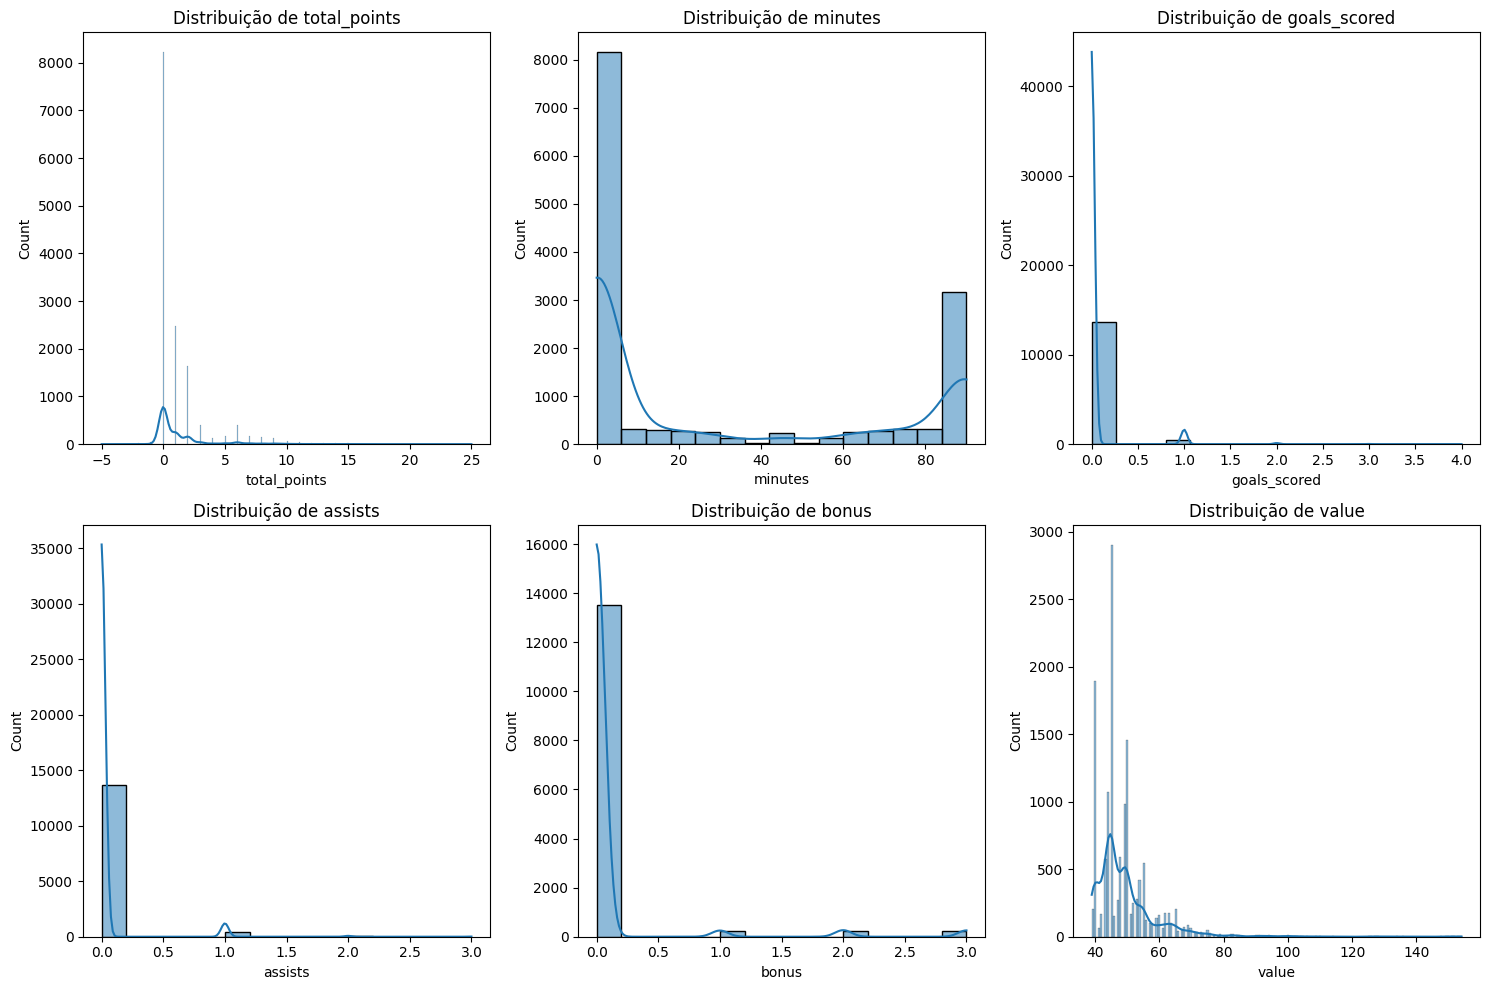

In [17]:
cols_to_plot = ['total_points', 'minutes', 'goals_scored', 'assists', 'bonus', 'value']

plt.figure(figsize=(15,10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribuição de {col}")
plt.tight_layout()
plt.show()


---

## 7. Análise Multivariada

Para compreender a relação entre métricas distintas, procede-se à visualização da matriz de correlação.  
Esta técnica ajuda a identificar padrões relevantes, como:

- métricas que se movem em conjunto,
- indicadores fortemente associados a pontuação,
- atributos redundantes.

Este conhecimento é essencial para inspirar a engenharia de atributos utilizada pelo algoritmo Apriori.


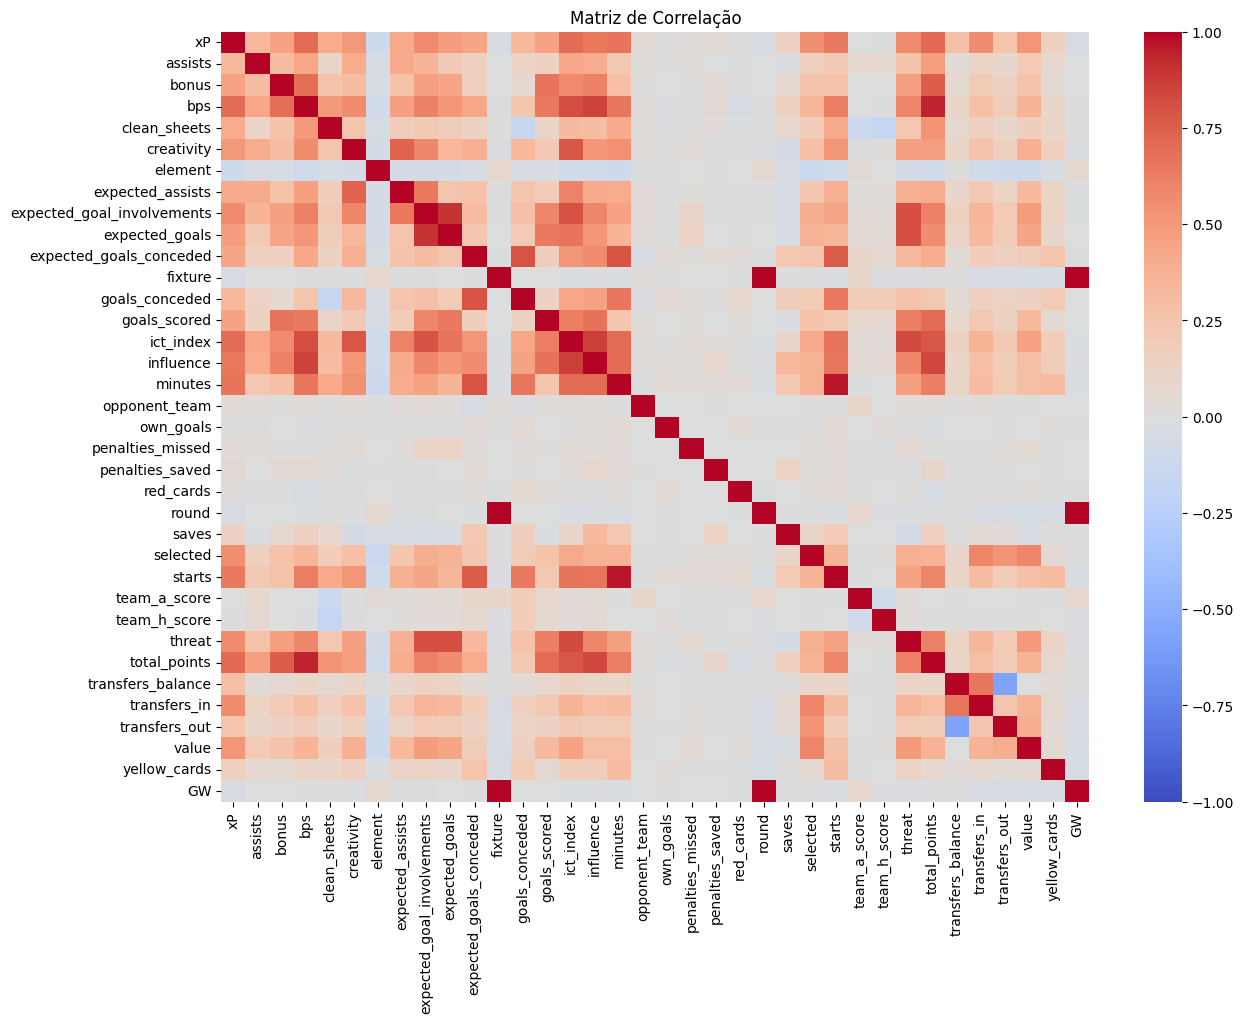

In [18]:
# compute correlation only on numeric columns to avoid string conversion errors
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação")
plt.show()

---

## 8. Engenharia de Atributos para o Apriori

Uma vez que o algoritmo Apriori opera sobre atributos **binários/categóricos**, é necessário transformar métricas contínuas em indicadores booleanos.

Assim, criam-se atributos como:

- high_points → jogador fez 8 ou mais pontos  
- played_60_plus → jogou pelo menos 60 minutos  
- goal_scored_flag → marcou pelo menos um golo  
- assist_flag → fez assistência  
- clean_sheet_flag → manteve clean sheet  
- high_influence / high_threat / high_creativity → métricas superiores à mediana

Estas variáveis definem a base transacional necessária para extração de regras de associação.

In [19]:
df['high_points'] = df['total_points'] >= 8
df['played_60_plus'] = df['minutes'] >= 60
df['goal_scored_flag'] = df['goals_scored'] > 0
df['assist_flag'] = df['assists'] > 0
df['clean_sheet_flag'] = df['clean_sheets'] > 0
df['high_influence'] = df['influence'] > df['influence'].median()
df['high_threat'] = df['threat'] > df['threat'].median()
df['high_creativity'] = df['creativity'] > df['creativity'].median()

---

## 9. Construção do Dataset Final para Regras de Associação

Após a criação dos atributos binários, selecionam-se apenas estes indicadores para formar o dataset que será utilizado pelo algoritmo Apriori.

Cada linha representa agora uma "transação" correspondente ao desempenho de um jogador numa jornada, descrita através da presença/ausência de determinados eventos.

In [20]:
df_transactions = df[['high_points', 'played_60_plus', 'goal_scored_flag',
                      'assist_flag', 'clean_sheet_flag',
                      'high_influence', 'high_threat', 'high_creativity']]

df_transactions.head()

,high_points,played_60_plus,goal_scored_flag,assist_flag,clean_sheet_flag,high_influence,high_threat,high_creativity
0,False,True,False,False,False,True,False,True
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,True,False,False,False,True,True,True


---

## 10. Conclusões da EDA

A análise exploratória permitiu concluir que:

1. O ficheiro `merged_gw.csv` apresenta informação altamente detalhada e adequada para análise de padrões de performance no FPL.
2. A limpeza e normalização dos dados foram essenciais para garantir consistência e qualidade:
   - conversão de tipos,
   - análise rigorosa dos nulos,
   - estudo das distribuições e relações entre métricas.
3. A criação de atributos binários foi fundamental para adaptar o dataset ao algoritmo Apriori.
4. O dataset final apresenta-se limpo, legível e estruturado, permitindo avançar para a análise de regras de associação.
5. Dado o tipo de atributos criados, será possível extrair regras como:
   - Jogadores que marcam golos tendem também a obter bónus ou alta influência.
   - Jogadores que jogam mais de 60 minutos têm maior probabilidade de atingir limiares de ameaça (threat).
   - Jogadores com boa performance ofensiva frequentemente exibem também elevada criatividade.

Com este trabalho, encontra-se concluída a EDA e inicia-se a fase de mineração de padrões.